In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
import os

# Check where Python is currently looking
print("Current directory:", os.getcwd())

# Check what's in the data folder
print("\nFiles in data folder:")
print(os.listdir('/Users/kimia.kb2000/projects/uk-brexit-analysis/data'))



Current directory: /Users/kimia.kb2000/projects/uk-brexit-analysis

Files in data folder:
['uk_gdp.csv', 'uk_inflation.csv']


In [5]:
gdp = pd.read_csv('/Users/kimia.kb2000/projects/uk-brexit-analysis/data/uk_gdp.csv')
inflation = pd.read_csv('/Users/kimia.kb2000/projects/uk-brexit-analysis/data/uk_inflation.csv')

print("=== GDP DATA ===")
print(gdp.head(10))
print("\nShape:", gdp.shape)

print("\n=== INFLATION DATA ===")
print(inflation.head(10))
print("\nShape:", inflation.shape)

=== GDP DATA ===
             Title  \
0             CDID   
1          PreUnit   
2             Unit   
3     Release Date   
4     Next release   
5  Important Notes   
6             1946   
7             1947   
8             1948   
9             1949   

  Gross Domestic Product at market prices, q-on-q1 growth: CP: NSA £m  \
0                                               A8L9                    
1                                                NaN                    
2                                                  %                    
3                                         14-05-2026                    
4                                       30 June 2026                    
5                                                NaN                    
6                                                NaN                    
7                                                NaN                    
8                                                NaN                    
9         

/var/folders/5h/9xc_2jp941b8wchnf20_nq500000gn/T/ipykernel_20483/4114582125.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251

In [7]:
with open('/Users/kimia.kb2000/projects/uk-brexit-analysis/data/uk_gdp.csv', 'r') as f:
    for i, line in enumerate(f):
        print(f"Row {i}: {line.strip()}")
        if i > 15:
            break

Row 0: "Title","Gross Domestic Product at market prices, q-on-q1 growth: CP: NSA £m","Gross Domestic Product at market prices, q-on-q4 growth: CP: NSA £m","General govt : subsidies - CYSA","Households (S.14): Individual consumption expenditure (P.31) Uses: Current price: £m: SA","Household final consumption expenditure :National concept CVM SA - £m","Total gross final expenditure (aligned) - P.3+P.5+P.6 : CP SA £m","Total gross final expenditure (aligned) - P.3+P.5+P.6 : CVM SA £m","Gross Domestic Product: chained volume measures: Seasonally adjusted £m","Gross Value Added (Average) at basic prices: CP SA £m","Gross Value Added at basic prices:chained volume measures:Seasonally adjusted £m","Household final consumption expenditure :Net tourist expenditure CVM SA £m","Gross Domestic Product: Quarter on Quarter growth: CVM NSA %","Gross Domestic Product: q-on-q4 growth rate CVM NSA %","Gross Domestic Product at market prices: CP: NSA £m","Gross Domestic Product: CVM: NSA £m","Trade in Go

In [8]:
# Read the file properly with headers
gdp_raw = pd.read_csv(
    '/Users/kimia.kb2000/projects/uk-brexit-analysis/data/uk_gdp.csv'
)

# See all column names
for col in gdp_raw.columns:
    print(col)

Title
Gross Domestic Product at market prices, q-on-q1 growth: CP: NSA £m
Gross Domestic Product at market prices, q-on-q4 growth: CP: NSA £m
General govt : subsidies - CYSA
Households (S.14): Individual consumption expenditure (P.31) Uses: Current price: £m: SA
Household final consumption expenditure :National concept CVM SA - £m
Total gross final expenditure (aligned) - P.3+P.5+P.6 : CP SA £m
Total gross final expenditure (aligned) - P.3+P.5+P.6 : CVM SA £m
Gross Domestic Product: chained volume measures: Seasonally adjusted £m
Gross Value Added (Average) at basic prices: CP SA £m
Gross Value Added at basic prices:chained volume measures:Seasonally adjusted £m
Household final consumption expenditure :Net tourist expenditure CVM SA £m
Gross Domestic Product: Quarter on Quarter growth: CVM NSA %
Gross Domestic Product: q-on-q4 growth rate CVM NSA %
Gross Domestic Product at market prices: CP: NSA £m
Gross Domestic Product: CVM: NSA £m
Trade in Goods (T): WW: Exports: BOP: CP: SA
Trade 

In [9]:
# Extract just the column we need
gdp_clean = gdp_raw[['Title', 'Gross Domestic Product: chained volume measures: Seasonally adjusted £m']].copy()

# Rename columns to something simple
gdp_clean.columns = ['date', 'gdp_value']

# Remove empty rows
gdp_clean = gdp_clean.dropna()

# Keep only annual rows (4 digit years like 1955, 1956...)
gdp_clean = gdp_clean[gdp_clean['date'].str.len() == 4]

# Reset index
gdp_clean = gdp_clean.reset_index(drop=True)

print(gdp_clean.head(20))
print("\nTotal rows:", len(gdp_clean))

    date gdp_value
0   CDID      ABMI
1   Unit         m
2   1948    455134
3   1949    470210
4   1950    485925
5   1951    503980
6   1952    511536
7   1953    539917
8   1954    563461
9   1955    586122
10  1956    596062
11  1957    607813
12  1958    615967
13  1959    642287
14  1960    682893
15  1961    701144
16  1962    708681
17  1963    742895
18  1964    785288
19  1965    801911

Total rows: 80


In [10]:
# Remove the first two rows (CDID and Unit rows)
gdp_clean = gdp_clean[2:].reset_index(drop=True)

# Convert columns to correct types
gdp_clean['date'] = gdp_clean['date'].astype(int)
gdp_clean['gdp_value'] = gdp_clean['gdp_value'].astype(float)

# Keep only years from 2010 onwards (relevant for Brexit analysis)
gdp_clean = gdp_clean[gdp_clean['date'] >= 2010]

print(gdp_clean)

    date  gdp_value
62  2010  2249959.0
63  2011  2269116.0
64  2012  2303794.0
65  2013  2343384.0
66  2014  2417439.0
67  2015  2469182.0
68  2016  2523665.0
69  2017  2599961.0
70  2018  2640295.0
71  2019  2673465.0
72  2020  2404838.0
73  2021  2610286.0
74  2022  2744708.0
75  2023  2752164.0
76  2024  2780775.0
77  2025  2819225.0


In [11]:
# Load inflation file and check column names
inflation_raw = pd.read_csv(
    '/Users/kimia.kb2000/projects/uk-brexit-analysis/data/uk_inflation.csv'
)

# Find the CPI column
for col in inflation_raw.columns:
    if 'CPI' in col or 'Consumer' in col or 'inflation' in col.lower():
        print(col)

CPI wts: Non-energy industrial goods GOODS
CPI wts: Durables GOODS
CPI wts: Semi-durables GOODS
CPI wts: Non-durables GOODS
CPI wts: Non-seasonal food GOODS
CPI wts: Food, alcoholic beverages & tobacco GOODS
CPI wts: Processed food & non-alcoholic beverages GOODS
CPI wts: Unprocessed food GOODS
CPI wts: Seasonal food GOODS
CPI wts: Industrial goods GOODS
CPI wts: Energy GOODS
CPI wts: Electricity, gas & misc. energy GOODS
CPI wts: CPI excluding tobacco SPECIAL AGGREGATES
CPI wts: Clothing & footwear goods GOODS
CPI wts: Housing goods GOODS
CPI wts: Household goods GOODS
CPI wts: Water supply; materials for maintenance & repair GOODS
CPI wts: Medical goods GOODS
CPI wts: Vehicles, spare parts & accessories GOODS
CPI wts: Recreational goods GOODS
CPI wts: Audio-visual goods GOODS
CPI wts: Other recreational goods GOODS
CPI wts: Miscellaneous goods GOODS
CPI wts: Housing services SERVICES
CPI wts: Primary housing services SERVICES
CPI wts: Other housing services SERVICES
CPI wts: Travel &

/var/folders/5h/9xc_2jp941b8wchnf20_nq500000gn/T/ipykernel_20483/2800780427.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251

In [12]:
# Find the main CPI column
for col in inflation_raw.columns:
    if 'CPI' in col and 'overall' in col.lower() or col == 'CPI INDEX 00: ALL ITEMS 2015=100':
        print(col)

# Also print first 5 columns to see what's at the start
print("\nFirst 5 columns:")
for col in list(inflation_raw.columns)[:5]:
    print(col)

CPI WEIGHTS 00 : HICP (Overall index)
CPI INDEX 00: ALL ITEMS 2015=100
CPIH WEIGHTS 00 : Overall index

First 5 columns:
Title
CPI wts: Non-energy industrial goods GOODS
CPI wts: Durables GOODS
CPI wts: Semi-durables GOODS
CPI wts: Non-durables GOODS


In [13]:
# Extract the main CPI column
inflation_clean = inflation_raw[['Title', 'CPI INDEX 00: ALL ITEMS 2015=100']].copy()

# Rename columns
inflation_clean.columns = ['date', 'cpi_value']

# Remove empty rows
inflation_clean = inflation_clean.dropna()

# Remove CDID and Unit rows
inflation_clean = inflation_clean[2:].reset_index(drop=True)

# Keep only annual rows (4 digit years)
inflation_clean = inflation_clean[inflation_clean['date'].str.len() == 4]

# Keep only from 2010 onwards
inflation_clean = inflation_clean[inflation_clean['date'].astype(int) >= 2010]

# Convert types
inflation_clean['date'] = inflation_clean['date'].astype(int)
inflation_clean['cpi_value'] = inflation_clean['cpi_value'].astype(float)

inflation_clean = inflation_clean.reset_index(drop=True)
print(inflation_clean)

    date  cpi_value
0   2010       89.4
1   2011       93.4
2   2012       96.1
3   2013       98.5
4   2014      100.0
5   2015      100.0
6   2016      100.7
7   2017      103.4
8   2018      105.9
9   2019      107.8
10  2020      108.7
11  2021      111.6
12  2022      121.7
13  2023      130.5
14  2024      133.9
15  2025      138.4


In [14]:
# Save clean datasets
gdp_clean.to_csv('/Users/kimia.kb2000/projects/uk-brexit-analysis/data/gdp_clean.csv', index=False)
inflation_clean.to_csv('/Users/kimia.kb2000/projects/uk-brexit-analysis/data/inflation_clean.csv', index=False)

print("Clean files saved successfully!")


Clean files saved successfully!


In [15]:
# Define Brexit referendum date
brexit_year = 2016

# Split GDP into pre and post Brexit
gdp_pre = gdp_clean[gdp_clean['date'] <= brexit_year]['gdp_value'].mean()
gdp_post = gdp_clean[gdp_clean['date'] > brexit_year]['gdp_value'].mean()

# Split inflation into pre and post Brexit
inf_pre = inflation_clean[inflation_clean['date'] <= brexit_year]['cpi_value'].mean()
inf_post = inflation_clean[inflation_clean['date'] > brexit_year]['cpi_value'].mean()

print("=== KEY FINDINGS ===")
print(f"Average GDP before Brexit: £{gdp_pre:,.0f}m")
print(f"Average GDP after Brexit:  £{gdp_post:,.0f}m")
print(f"\nAverage CPI before Brexit: {inf_pre:.1f}")
print(f"Average CPI after Brexit:  {inf_post:.1f}")

=== KEY FINDINGS ===
Average GDP before Brexit: £2,368,077m
Average GDP after Brexit:  £2,669,524m

Average CPI before Brexit: 96.9
Average CPI after Brexit:  118.0


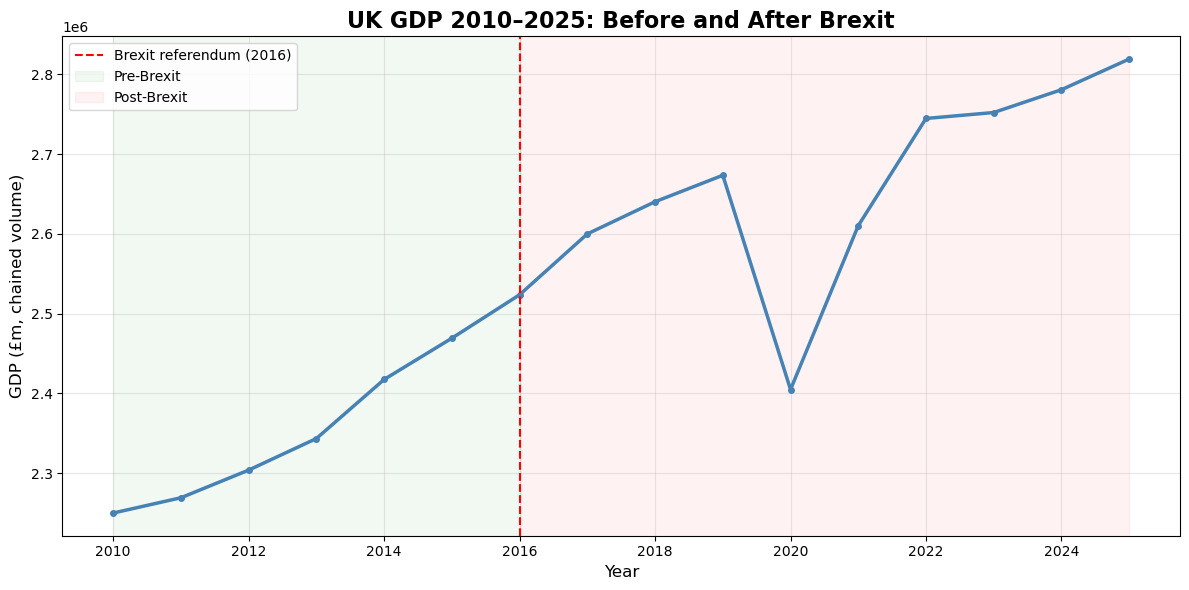

GDP chart saved!


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot GDP line
ax.plot(gdp_clean['date'], gdp_clean['gdp_value'], 
        color='steelblue', linewidth=2.5, marker='o', markersize=4)

# Add Brexit vertical line
ax.axvline(x=2016, color='red', linestyle='--', linewidth=1.5, label='Brexit referendum (2016)')

# Shade pre and post Brexit areas
ax.axvspan(2010, 2016, alpha=0.05, color='green', label='Pre-Brexit')
ax.axvspan(2016, 2025, alpha=0.05, color='red', label='Post-Brexit')

# Labels and formatting
ax.set_title('UK GDP 2010–2025: Before and After Brexit', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GDP (£m, chained volume)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/kimia.kb2000/projects/uk-brexit-analysis/charts/gdp_chart.png', dpi=150)
plt.show()
print("GDP chart saved!")

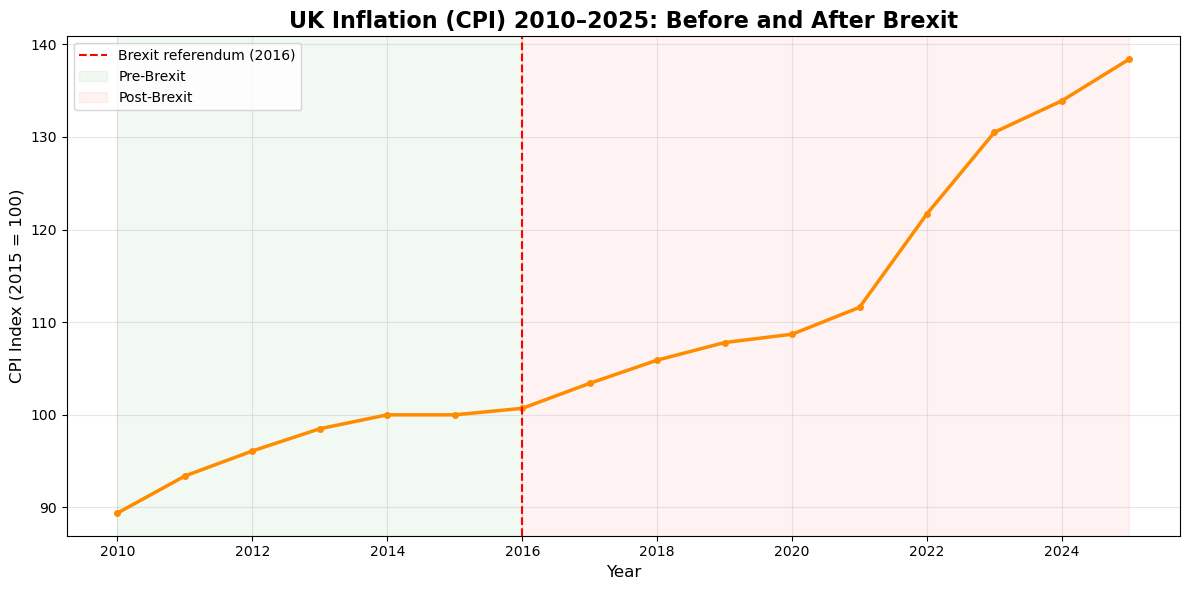

Inflation chart saved!


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot inflation line
ax.plot(inflation_clean['date'], inflation_clean['cpi_value'],
        color='darkorange', linewidth=2.5, marker='o', markersize=4)

# Add Brexit vertical line
ax.axvline(x=2016, color='red', linestyle='--', linewidth=1.5, label='Brexit referendum (2016)')

# Shade areas
ax.axvspan(2010, 2016, alpha=0.05, color='green', label='Pre-Brexit')
ax.axvspan(2016, 2025, alpha=0.05, color='red', label='Post-Brexit')

# Labels and formatting
ax.set_title('UK Inflation (CPI) 2010–2025: Before and After Brexit', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CPI Index (2015 = 100)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/kimia.kb2000/projects/uk-brexit-analysis/charts/inflation_chart.png', dpi=150)
plt.show()
print("Inflation chart saved!")

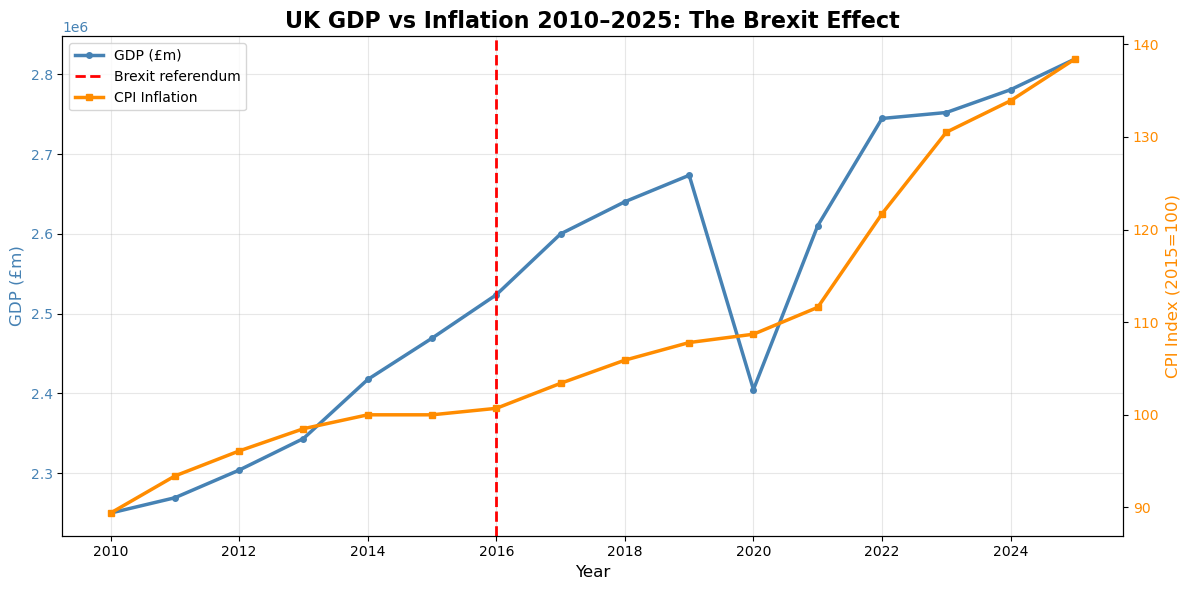

Combined chart saved!


In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# GDP on left axis
ax1.plot(gdp_clean['date'], gdp_clean['gdp_value'],
         color='steelblue', linewidth=2.5, marker='o', markersize=4, label='GDP (£m)')
ax1.set_ylabel('GDP (£m)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Inflation on right axis
ax2 = ax1.twinx()
ax2.plot(inflation_clean['date'], inflation_clean['cpi_value'],
         color='darkorange', linewidth=2.5, marker='s', markersize=4, label='CPI Inflation')
ax2.set_ylabel('CPI Index (2015=100)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Brexit line
ax1.axvline(x=2016, color='red', linestyle='--', linewidth=2, label='Brexit referendum')

# Title and formatting
ax1.set_title('UK GDP vs Inflation 2010–2025: The Brexit Effect', 
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig('/Users/kimia.kb2000/projects/uk-brexit-analysis/charts/gdp_vs_inflation.png', dpi=150)
plt.show()
print("Combined chart saved!")